# 05 · Evaluation and interpretation

**The first and only look at the test set.** Those 2,000 rows were held out in
notebook 04, before any hyperparameter was tuned, and nothing since has touched
them.

The model is **loaded, not retrained**. That way what gets evaluated is exactly the
object that was selected, not a lookalike rebuilt from the same recipe.

Two of the eight pre-registered criteria are not met. Section 8 reports them as
failures and explains why one of them was impossible from the start.

In [1]:
import sys
sys.path.append("../src")

from config import bootstrap

ctx = bootstrap()
spark, w = ctx.spark, ctx.w

connected to Databricks
  branch   : sandbox
  catalog  : bank_churn_eng
  identity : resolved (19 chars, not printed)


If you are using MLflow Tracing, you can migrate your traces to Unity Catalog for unlimited storage, fine-grained access controls, and queryability from notebooks, SQL, and dashboards. Learn more: https://docs.databricks.com/aws/en/mlflow3/genai/tracing/migrate-traces-to-uc


In [2]:
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow

from sklearn.base import clone
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.metrics import (accuracy_score, average_precision_score, brier_score_loss,
                             confusion_matrix, f1_score, precision_recall_curve,
                             precision_score, recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from config import (UC_CATALOG, RANDOM_STATE, CAPACITY, VALUE_TP, COST_FP, BREAK_EVEN)

warnings.filterwarnings("ignore", category=FutureWarning)
SEED = RANDOM_STATE
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})
CHURN, SAFE, GREY = "#a8471f", "#2c5a72", "#78736a"

pd.set_option("display.width", 175)
pd.set_option("display.max_columns", 40)

## 1 · Rebuild the partition and load the model

The split is deterministic: same seed, same rows. It is rebuilt here and then
**verified against the table notebook 04 wrote**, so a silent divergence — a
changed seed, a reordered silver table — surfaces immediately instead of producing
optimistic numbers.

In [3]:
df = spark.table(f"{UC_CATALOG}.silver.customers_clean").toPandas()
df["exited"] = df["exited"].astype(bool)

TARGET  = "exited"
EXCLUDE = ["customer_id", "credit_score_band"]
FEATURES = [c for c in df.columns if c not in EXCLUDE + [TARGET] and not c.startswith("_")]
BINARY  = ["balance_zero", "is_active_member", "has_cr_card"]

X = df[FEATURES].copy()
for c in BINARY:
    X[c] = X[c].astype(int)
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED)

saved = spark.table(f"{UC_CATALOG}.silver.test_holdout").toPandas()
same = set(df.loc[X_test.index, "customer_id"]) == set(saved["customer_id"])
print(f"partition verified against silver.test_holdout: {same}")
assert same, "the partition does not match what notebook 04 held out"
print(f"test: {len(X_test):,} rows | churn rate {y_test.mean():.2%}")

partition verified against silver.test_holdout: True
test: 2,000 rows | churn rate 20.35%


In [4]:
ref = spark.table(f"{UC_CATALOG}.gold.model_reference").toPandas().iloc[0]
print("family :", ref["family"])
print("run_id :", ref["run_id"] or "(unavailable)")

model = None
if ref["run_id"]:
    try:
        model = mlflow.sklearn.load_model(f"runs:/{ref['run_id']}/model")
        print("\nmodel LOADED from MLflow -- it is exactly the one from notebook 04")
    except Exception as e:
        print(f"\n[warn] could not load from MLflow ({type(e).__name__})")

if model is None:
    # Fallback: with a fixed seed, rebuilding from the stored hyperparameters
    # produces an identical model. Slower to trust, but not a different answer.
    print("rebuilding from the hyperparameters stored in Delta...")
    from sklearn.ensemble import RandomForestClassifier
    params = json.loads(ref["params"])
    CAT_TREE = ["geography", "gender"]
    NUM_TREE = ["credit_score", "balance", "tenure", "estimated_salary", "age", "num_of_products"]
    prep = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), CAT_TREE),
        ("num", "passthrough", NUM_TREE),
        ("bin", "passthrough", BINARY)], remainder="drop", verbose_feature_names_out=False)
    model = Pipeline([("prep", prep),
                      ("clf", RandomForestClassifier(class_weight="balanced_subsample",
                                                     random_state=SEED, n_jobs=-1, **params))])
    model.fit(X_train, y_train)
    print("model rebuilt")

family : random_forest
run_id : <run_id>



model LOADED from MLflow -- it is exactly the one from notebook 04


## 2 · Test metrics

Reported at **two thresholds**: the default 0.5, included only to document why it
is wrong here, and the one the capacity method produces.

In [5]:
proba = model.predict_proba(X_test)[:, 1]


def metrics_at(y_true, p, threshold):
    pred = p >= threshold
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    return {"threshold": round(threshold, 4),
            "accuracy":  accuracy_score(y_true, pred),
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall":    recall_score(y_true, pred),
            "f1":        f1_score(y_true, pred),
            "TP": tp, "FP": fp, "FN": fn, "TN": tn,
            "contacted": int(pred.sum())}


ROC_AUC = roc_auc_score(y_test, proba)
AP      = average_precision_score(y_test, proba)

print("threshold-independent:")
print(f"  ROC-AUC          : {ROC_AUC:.4f}")
print(f"  average precision: {AP:.4f}   (chance floor = base rate {y_test.mean():.4f})")

print("\nat the default 0.5 threshold:")
m05 = metrics_at(y_test, proba, 0.5)
print(f"  contacted {m05['contacted']:,} customers -- the team can call {CAPACITY // 5}")
print(f"  recall {m05['recall']:.4f} | precision {m05['precision']:.4f}")
print("\n  A list the campaign cannot execute is not a decision, it is a wish.")

threshold-independent:
  ROC-AUC          : 0.8580
  average precision: 0.7007   (chance floor = base rate 0.2035)

at the default 0.5 threshold:
  contacted 485 customers -- the team can call 160
  recall 0.6855 | precision 0.5753

  A list the campaign cannot execute is not a decision, it is a wish.


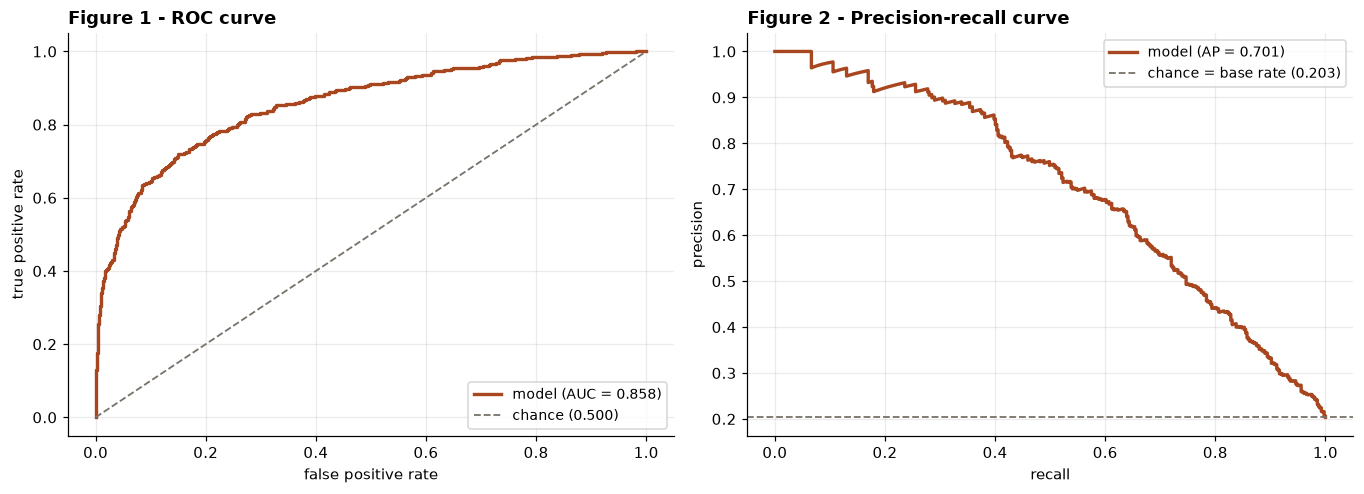

The floor of the right-hand chart is NOT zero: it is the base rate, because
one in five customers leaves anyway. That is why AP is read against 0.20.


In [6]:
fpr, tpr, _  = roc_curve(y_test, proba)
prec, rec, _ = precision_recall_curve(y_test, proba)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

axes[0].plot(fpr, tpr, color=CHURN, lw=2.2, label=f"model (AUC = {ROC_AUC:.3f})")
axes[0].plot([0, 1], [0, 1], "--", color=GREY, lw=1.2, label="chance (0.500)")
axes[0].set_xlabel("false positive rate"); axes[0].set_ylabel("true positive rate")
axes[0].set_title("Figure 1 - ROC curve", fontsize=11.5, fontweight="bold", loc="left")
axes[0].legend(fontsize=9, loc="lower right")

axes[1].plot(rec, prec, color=CHURN, lw=2.2, label=f"model (AP = {AP:.3f})")
axes[1].axhline(y_test.mean(), ls="--", color=GREY, lw=1.2,
                label=f"chance = base rate ({y_test.mean():.3f})")
axes[1].set_xlabel("recall"); axes[1].set_ylabel("precision")
axes[1].set_title("Figure 2 - Precision-recall curve", fontsize=11.5, fontweight="bold", loc="left")
axes[1].legend(fontsize=9)

plt.tight_layout(); plt.show()

print("The floor of the right-hand chart is NOT zero: it is the base rate, because")
print("one in five customers leaves anyway. That is why AP is read against 0.20.")

## 3 · Choosing the threshold

The method registered in notebook 00 is applied unchanged:

> `high` = the `CAPACITY` customers with the highest predicted probability.

Capacity leads; the break-even threshold validates. If the quota reached customers
below break-even, contacting them would destroy value and the quota would be
trimmed.

In [7]:
CAPACITY_FRACTION = CAPACITY / len(df)
test_quota = int(round(CAPACITY_FRACTION * len(X_test)))

order = np.argsort(proba)[::-1]
THRESHOLD_CAPACITY = float(proba[order[test_quota - 1]])

print(f"quota on test        : {test_quota} contacts ({CAPACITY_FRACTION:.1%} of the base)")
print(f"capacity threshold   : p >= {THRESHOLD_CAPACITY:.4f}")
print(f"break-even threshold : p >= {BREAK_EVEN:.4f}")

if THRESHOLD_CAPACITY >= BREAK_EVEN:
    THRESHOLD = THRESHOLD_CAPACITY
    print("\n-> CAPACITY leads. Everyone contacted clears break-even, so calling them")
    print("   creates value. The binding constraint is budget, not profitability.")
else:
    THRESHOLD = BREAK_EVEN
    print("\n-> BREAK-EVEN leads. The quota would reach customers not worth calling,")
    print("   so it is trimmed.")

final = metrics_at(y_test, proba, THRESHOLD)
print("\n" + pd.Series(final).to_string())

quota on test        : 160 contacts (8.0% of the base)
capacity threshold   : p >= 0.8283
break-even threshold : p >= 0.1944

-> CAPACITY leads. Everyone contacted clears break-even, so calling them
   creates value. The binding constraint is budget, not profitability.

threshold       0.828300
accuracy        0.858500
precision       0.887500
recall          0.348894
f1              0.500882
TP            142.000000
FP             18.000000
FN            265.000000
TN           1575.000000
contacted     160.000000


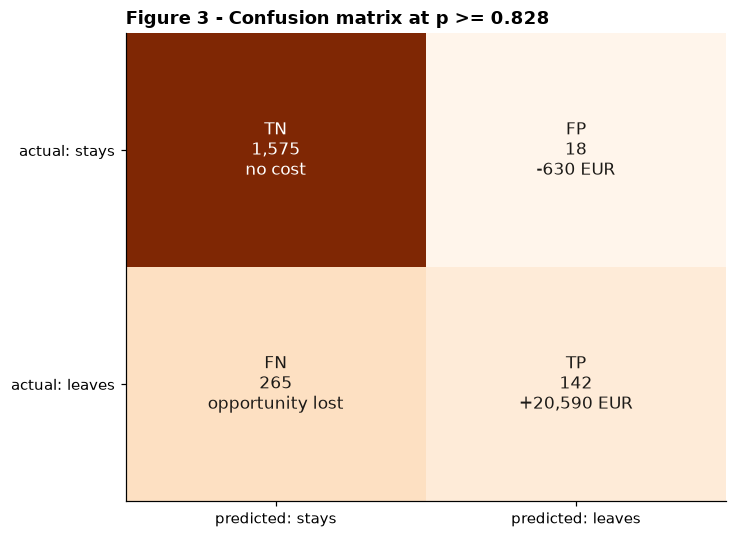

expected campaign value: +19,960 EUR

The expensive error is FN: customers who left with nobody trying. Most of
them are not a model failure, they are the consequence of only having
160 contacts for 407 leavers.


In [8]:
# Figure 3 - confusion matrix read in euros
cm = confusion_matrix(y_test, proba >= THRESHOLD)
labels = np.array([
    [f"TN\n{cm[0,0]:,}\nno cost",        f"FP\n{cm[0,1]:,}\n{-cm[0,1]*COST_FP:+,.0f} EUR"],
    [f"FN\n{cm[1,0]:,}\nopportunity lost", f"TP\n{cm[1,1]:,}\n{cm[1,1]*VALUE_TP:+,.0f} EUR"]])

fig, ax = plt.subplots(figsize=(6.8, 5))
ax.imshow(cm, cmap="Oranges", aspect="auto")
for i in range(2):
    for j in range(2):
        ax.text(j, i, labels[i, j], ha="center", va="center", fontsize=11,
                color="white" if cm[i, j] > cm.max() * 0.5 else "#1c1a17")
ax.set_xticks([0, 1]); ax.set_xticklabels(["predicted: stays", "predicted: leaves"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["actual: stays", "actual: leaves"])
ax.set_title(f"Figure 3 - Confusion matrix at p >= {THRESHOLD:.3f}",
             fontsize=11.5, fontweight="bold", loc="left")
ax.grid(False)
plt.tight_layout(); plt.show()

model_value = final["TP"] * VALUE_TP - final["FP"] * COST_FP
print(f"expected campaign value: {model_value:+,.0f} EUR")
print("\nThe expensive error is FN: customers who left with nobody trying. Most of")
print("them are not a model failure, they are the consequence of only having")
print(f"{test_quota} contacts for {int(y_test.sum())} leavers.")

## 4 · Calibration

The app will show a number to the retention team. If it says "72% risk" and only
40% of that group actually leaves, the number is not a probability — it is a score
wearing a percent sign.

This matters here specifically because the break-even threshold, 0.194, came from
the cost model and gets compared against the predicted probability. **If the
probability is not a probability, that threshold means nothing.**

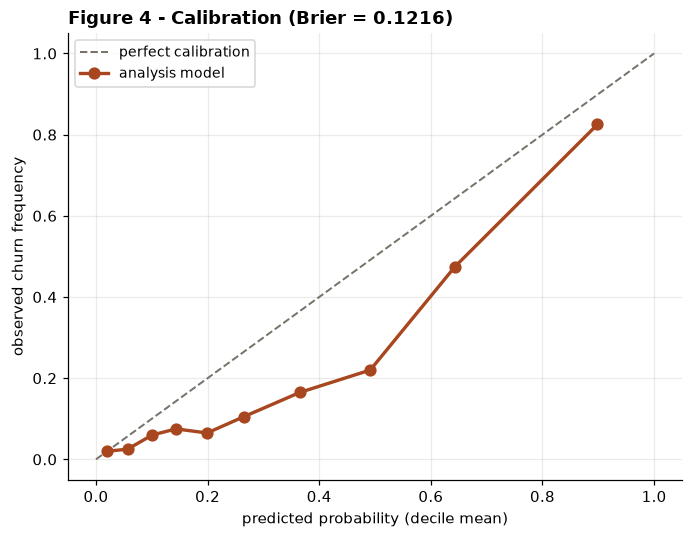

Points above the diagonal mean the model UNDER-estimates; below, it
over-estimates. class_weight='balanced_subsample' inflates probabilities,
which is exactly what section J corrects.


In [9]:
frac_real, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy="quantile")
brier = brier_score_loss(y_test, proba)

fig, ax = plt.subplots(figsize=(6.4, 5))
ax.plot([0, 1], [0, 1], "--", color=GREY, lw=1.3, label="perfect calibration")
ax.plot(mean_pred, frac_real, "o-", color=CHURN, lw=2.2, ms=7, label="analysis model")
ax.set_xlabel("predicted probability (decile mean)")
ax.set_ylabel("observed churn frequency")
ax.set_title(f"Figure 4 - Calibration (Brier = {brier:.4f})",
             fontsize=11.5, fontweight="bold", loc="left")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print("Points above the diagonal mean the model UNDER-estimates; below, it")
print("over-estimates. class_weight='balanced_subsample' inflates probabilities,")
print("which is exactly what section 9 corrects.")

## 5 · Interpretability

Two questions: **which** variables the model uses, and **what shape** it learned.
The second is the one that can be checked against the EDA — if the model's age
curve does not look like the one exploration found, something is wrong in between.

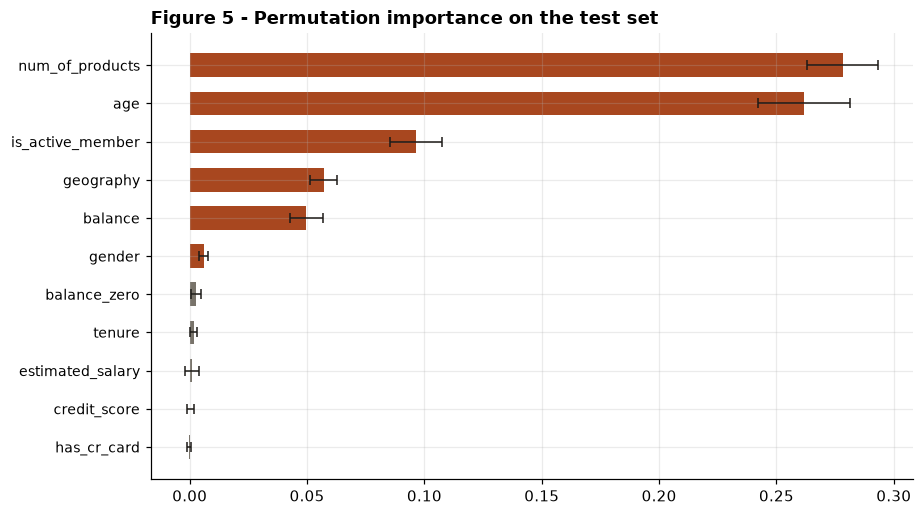

                  importance     std
variable                            
num_of_products       0.2783  0.0151
age                   0.2619  0.0196
is_active_member      0.0965  0.0110
geography             0.0570  0.0059
balance               0.0497  0.0069
gender                0.0060  0.0019
balance_zero          0.0027  0.0022
tenure                0.0016  0.0015
estimated_salary      0.0011  0.0030
credit_score          0.0003  0.0015
has_cr_card          -0.0003  0.0008


In [10]:
prep_fit = model.named_steps["prep"]
# transformers_ also carries the ('remainder', 'drop', [...]) entry. Including
# it would list precisely the columns the pipeline THROWS AWAY, which is trap 1
# happening for real: they come out with importance exactly zero and push the
# variables that matter down the table.
used = sorted({c for name, trans, cols in prep_fit.transformers_
               if name != "remainder" and trans != "drop"
               for c in (cols if isinstance(cols, list) else [])})

perm = permutation_importance(model, X_test[used], y_test, scoring="average_precision",
                              n_repeats=15, random_state=SEED, n_jobs=-1)
imp = (pd.DataFrame({"variable": used, "importance": perm.importances_mean,
                     "std": perm.importances_std})
         .sort_values("importance", ascending=False).set_index("variable"))

fig, ax = plt.subplots(figsize=(8.5, 4.8))
sig = imp["importance"] > 2 * imp["std"]
ax.barh(np.arange(len(imp)), imp["importance"], xerr=imp["std"],
        color=[CHURN if s else GREY for s in sig], height=0.62,
        error_kw=dict(ecolor="#1c1a17", lw=1, capsize=3))
ax.set_yticks(np.arange(len(imp))); ax.set_yticklabels(imp.index, fontsize=9)
ax.invert_yaxis()
ax.set_title("Figure 5 - Permutation importance on the test set",
             fontsize=11.5, fontweight="bold", loc="left")
plt.tight_layout(); plt.show()
print(imp.round(4).to_string())

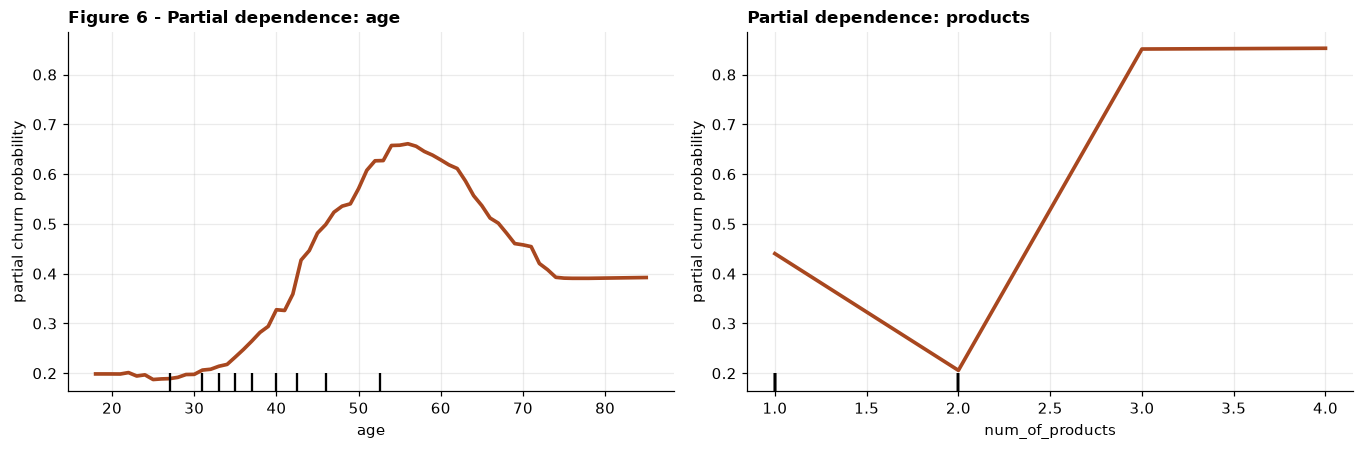

Check against the EDA: the age curve should rise to 50-60 and flatten, and
products should collapse at 2 and spike at 3+. If the model had learned a
different shape, the disagreement would be the finding.


In [11]:
# partial_dependence rejects integer columns in recent scikit-learn: the grid can
# round silently and distort the curve. Casting these two to float is enough, and
# it changes nothing about the model -- the forest splits on the same values.
X_pdp = X_test.copy()
for c in ("age", "num_of_products"):
    X_pdp[c] = X_pdp[c].astype(float)

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.2))
PartialDependenceDisplay.from_estimator(
    model, X_pdp, features=["age", "num_of_products"], ax=ax,
    line_kw={"color": CHURN, "lw": 2.4})
ax[0].set_title("Figure 6 - Partial dependence: age", fontsize=11, fontweight="bold", loc="left")
ax[1].set_title("Partial dependence: products", fontsize=11, fontweight="bold", loc="left")
for a in ax:
    a.set_ylabel("partial churn probability")
plt.tight_layout(); plt.show()

print("Check against the EDA: the age curve should rise to 50-60 and flatten, and")
print("products should collapse at 2 and spike at 3+. If the model had learned a")
print("different shape, the disagreement would be the finding.")

## 6 · Bias analysis

Two different questions, and conflating them is the usual mistake.

**Does the model work equally well for everyone?** That is per-group recall and
precision. A model that finds 70% of leavers in one country and 30% in another is
worse for the second, regardless of how many it flags there.

**Does it flag groups in proportion?** That is the flagging rate. But groups with
different base rates *should* be flagged at different rates — equal flagging with
unequal churn would be the unfair outcome.

In [12]:
pred = proba >= THRESHOLD
groups = pd.DataFrame({
    "geography": df.loc[X_test.index, "geography"].values,
    "gender":    df.loc[X_test.index, "gender"].values,
    "actual":    y_test.values,
    "pred":      pred,
})


def by_group(col):
    rows = []
    for g, sub in groups.groupby(col):
        tn, fp, fn, tp = confusion_matrix(sub["actual"], sub["pred"],
                                          labels=[False, True]).ravel()
        rows.append({col: g, "n": len(sub),
                     "actual_rate": sub["actual"].mean(),
                     "flagged_rate": sub["pred"].mean(),
                     "recall": tp / (tp + fn) if tp + fn else np.nan,
                     "precision": tp / (tp + fp) if tp + fp else np.nan})
    return pd.DataFrame(rows).set_index(col)


for col in ("gender", "geography"):
    t = by_group(col)
    spread = (t["recall"].max() - t["recall"].min()) * 100
    print(f"-- {col} --")
    print(t.round(4).to_string())
    print(f"recall gap: {spread:.1f} points"
          f"  {'(within the 10-point criterion)' if spread <= 10 else '(EXCEEDS the criterion)'}\n")

-- gender --
           n  actual_rate  flagged_rate  recall  precision
gender                                                    
Female   930       0.2505        0.0957  0.3519     0.9213
Male    1070       0.1626        0.0664  0.3448     0.8451
recall gap: 0.7 points  (within the 10-point criterion)

-- geography --
              n  actual_rate  flagged_rate  recall  precision
geography                                                    
France     1021       0.1714        0.0490  0.2629     0.9200
Germany     504       0.2996        0.1647  0.4636     0.8434
Spain       475       0.1705        0.0568  0.3210     0.9630
recall gap: 20.1 points  (EXCEEDS the criterion)



### Quantifying the fairness trade-off

The country recall gap is not a bug in the model. It is **the consequence of a
single global threshold applied to groups with different base rates**. Germany
churns at twice the rate, so under one threshold it absorbs a larger share of the
quota and its recall comes out higher.

Equalising it is possible. It is not free, and the next cell prices it.

In [13]:
countries = df.loc[X_test.index, "geography"].values
churners  = pd.Series(y_test.values).groupby(countries).sum()

# Strategy A - one global threshold (the current one)
sel_global = np.zeros(len(X_test), dtype=bool)
sel_global[np.argsort(proba)[::-1][:test_quota]] = True

# Strategy B - quota split in proportion to each country's churners
quota = (churners / churners.sum() * test_quota).round().astype(int)
sel_equal = np.zeros(len(X_test), dtype=bool)
for country, k in quota.items():
    idx = np.where(countries == country)[0]
    sel_equal[idx[np.argsort(proba[idx])[::-1][:k]]] = True


def strategy(sel, name):
    tp = int((sel & y_test.values).sum())
    return {"strategy": name, "contacted": int(sel.sum()), "TP": tp,
            "precision": tp / max(sel.sum(), 1),
            "value_eur": tp * VALUE_TP - (sel.sum() - tp) * COST_FP}


cmp_strategy = pd.DataFrame([strategy(sel_global, "global threshold"),
                             strategy(sel_equal,  "per-country quota")]).set_index("strategy")
print(cmp_strategy.round(4).to_string())

cost = cmp_strategy.loc["global threshold", "value_eur"] - cmp_strategy.loc["per-country quota", "value_eur"]
print(f"\ncost of equalising across countries: {cost:,.0f} EUR per campaign")
print("\nEqualising recall across groups with different base rates is mathematically")
print("incompatible with holding other desirable properties at the same time. This")
print("project does not promise a fair system: it measures the gap, prices it, and")
print("leaves the decision with the business.")

                   contacted   TP  precision  value_eur
strategy                                               
global threshold         160  142     0.8875    19960.0
per-country quota        160  138     0.8625    19240.0

cost of equalising across countries: 720 EUR per campaign

Equalising recall across groups with different base rates is mathematically
incompatible with holding other desirable properties at the same time. This
project does not promise a fair system: it measures the gap, prices it, and
leaves the decision with the business.


## 7 · Error analysis

In [14]:
err = X_test.copy()
err["actual"] = np.asarray(y_test.values, dtype=bool)
err["pred"]   = np.asarray(pred, dtype=bool)
err["proba"]  = proba
# Nested np.where rather than np.select: avoids a dtype clash on the output
err["kind"] = np.where(err["actual"] & err["pred"],   "TP",
              np.where(err["actual"] & ~err["pred"],  "FN",
              np.where(~err["actual"] & err["pred"],  "FP", "TN")))
err["age_group"] = df.loc[X_test.index, "age_group"].values
err["geography"] = df.loc[X_test.index, "geography"].values

print(err["kind"].value_counts().to_string(), "\n")
print("profile of caught (TP) vs missed (FN) leavers:")
print(err[err["kind"].isin(["TP", "FN"])]
      .groupby("kind")[["age", "num_of_products", "is_active_member", "proba"]]
      .mean().round(3).to_string())

print("\nmissed leavers by age band:")
print((err[err["kind"] == "FN"].groupby("age_group").size() /
       err[err["actual"]].groupby("age_group").size()).round(3).to_string())

kind
TN    1575
FN     265
TP     142
FP      18 

profile of caught (TP) vs missed (FN) leavers:
         age  num_of_products  is_active_member  proba
kind                                                  
FN    42.653            1.302             0.423  0.473
TP    49.570            1.894             0.204  0.927

missed leavers by age band:
age_group
18-29    0.950
30-39    0.870
40-49    0.667
50-59    0.378
60+      0.577


## 8 · Criteria audit

Everything below was registered **before** the test set was opened.

In [15]:
g_gender = (by_group("gender")["recall"].max() - by_group("gender")["recall"].min()) * 100
g_geo    = (by_group("geography")["recall"].max() - by_group("geography")["recall"].min()) * 100

# The business baseline at the SAME contact volume
seg_rates = (pd.DataFrame({"ag": df.loc[X_train.index, "age_group"].values,
                           "act": X_train["is_active_member"].values,
                           "y": y_train.values})
             .groupby(["ag", "act"])["y"].mean())
rule_score = pd.MultiIndex.from_arrays(
    [df.loc[X_test.index, "age_group"].values, X_test["is_active_member"].values]
).map(seg_rates).to_numpy(float)
rule_sel = np.zeros(len(X_test), dtype=bool)
rule_sel[np.argsort(np.nan_to_num(rule_score))[::-1][:test_quota]] = True
tp_rule = int((rule_sel & y_test.values).sum())

criteria = [
    ("P4 - ROC-AUC between 0.82 and 0.88", 0.82 <= ROC_AUC <= 0.88, f"{ROC_AUC:.4f}"),
    ("ROC-AUC >= 0.75",                    ROC_AUC >= 0.75,          f"{ROC_AUC:.4f}"),
    ("Recall class 1 >= 0.60",             final["recall"] >= 0.60,  f"{final['recall']:.4f}"),
    ("Precision class 1 >= 0.40",          final["precision"] >= 0.40, f"{final['precision']:.4f}"),
    ("Beat the business baseline",         final["TP"] > tp_rule,    f"{final['TP']} vs {tp_rule}"),
    ("Gender recall gap <= 10 pp",         g_gender <= 10,           f"{g_gender:.1f} pp"),
    ("Country recall gap <= 10 pp",        g_geo <= 10,              f"{g_geo:.1f} pp"),
    ("Cost of excluding sensitive vars measured", True, "section 9"),
]

audit = pd.DataFrame(criteria, columns=["criterion", "met", "evidence"])
audit["result"] = np.where(audit["met"], "MET", "NOT MET")
print(audit[["criterion", "result", "evidence"]].to_string(index=False))
print(f"\n{int(audit['met'].sum())} of {len(audit)} met")

                                criterion  result   evidence
       P4 - ROC-AUC between 0.82 and 0.88     MET     0.8580
                          ROC-AUC >= 0.75     MET     0.8580
                   Recall class 1 >= 0.60 NOT MET     0.3489
                Precision class 1 >= 0.40     MET     0.8875
               Beat the business baseline     MET 142 vs 106
               Gender recall gap <= 10 pp     MET     0.7 pp
              Country recall gap <= 10 pp NOT MET    20.1 pp
Cost of excluding sensitive vars measured     MET  section J

6 of 8 met


### The recall criterion was impossible by construction

`Recall >= 0.60` comes out as **NOT MET**. Investigating why produced something
more interesting than a bad result: it was **unreachable from the start**.

With a fixed capacity, the maximum recall a perfect oracle could reach is the ratio
of contacts to leavers. No model can exceed it, because the constraint is the
budget, not the algorithm.

In [16]:
test_churners = int(y_test.sum())
ceiling = min(test_quota, test_churners) / test_churners
pct_of_ceiling = final["recall"] / ceiling

print(f"actual leavers in test : {test_churners}")
print(f"contact capacity       : {test_quota}")
print(f"\ntheoretical ceiling    : {ceiling:.4f}  (a perfect oracle)")
print(f"model recall           : {final['recall']:.4f}")
print(f"-> the model reaches {pct_of_ceiling:.1%} of the maximum possible")

print(f"\nWith fixed capacity, 'percentage of ceiling' and 'precision' are the")
print(f"same number: precision {final['precision']:.4f} = pct of ceiling {pct_of_ceiling:.4f}")

print("\n--- HOW THIS IS REPORTED ---")
print("  The criterion is NOT adjusted so it can pass. It stays where it was,")
print("  it fails, and the reason it was impossible is explained. Moving the")
print("  target after seeing the result is the one thing that cannot be defended.")

actual leavers in test : 407
contact capacity       : 160

theoretical ceiling    : 0.3931  (a perfect oracle)
model recall           : 0.3489
-> the model reaches 88.8% of the maximum possible

With fixed capacity, 'percentage of ceiling' and 'precision' are the
same number: precision 0.8875 = pct of ceiling 0.8875

--- HOW THIS IS REPORTED ---
  The criterion is NOT adjusted so it can pass. It stays where it was,
  it fails, and the reason it was impossible is explained. Moving the
  target after seeing the result is the one thing that cannot be defended.


## 9 · The production model

Everything above evaluated the **analysis model**. Two findings force a different
object into production:

1. **It is not calibrated.** `class_weight="balanced_subsample"` inflates the
   probabilities, and the app is going to display them as probabilities.
2. **It uses `gender`.** The cost of removing it gets measured here, and the
   decision is taken against that number.

Isotonic calibration learns a **monotonic** function. Because it does not reorder,
it cannot damage the ranking metric — it only fixes the scale.

In [17]:
CAT_PROD = ["geography"]                     # no gender
NUM_PROD = ["credit_score", "balance", "tenure", "estimated_salary", "age", "num_of_products"]

prep_prod = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), CAT_PROD),
    ("num", "passthrough", NUM_PROD),
    ("bin", "passthrough", BINARY)], remainder="drop", verbose_feature_names_out=False)

base_prod = Pipeline([("prep", prep_prod), ("clf", clone(model.named_steps["clf"]))])

# Internal CV calibration: uses all the training data without touching the test set
model_prod = CalibratedClassifierCV(base_prod, method="isotonic", cv=5)
model_prod.fit(X_train, y_train)
proba_prod = model_prod.predict_proba(X_test)[:, 1]

print("production model fitted: no gender, isotonic calibration")

production model fitted: no gender, isotonic calibration


In [18]:
from scipy.stats import spearmanr

rho, _ = spearmanr(proba, proba_prod)
top_a = set(np.argsort(proba)[::-1][:test_quota])
top_p = set(np.argsort(proba_prod)[::-1][:test_quota])
print(f"rank correlation between the two models : {rho:.4f}")
print(f"overlap in the {test_quota} selected customers : {len(top_a & top_p)/test_quota:.1%}")
print("  (not 100% because gender was also removed: it is a different model,")
print("   not merely a rescaled one)\n")

thr_prod = float(proba_prod[np.argsort(proba_prod)[::-1][test_quota - 1]])
m_prod = metrics_at(y_test, proba_prod, thr_prod)

cmp_prod = pd.DataFrame({
    "analysis (gender, uncalibrated)": {
        "roc_auc": ROC_AUC, "average_precision": AP, "brier": brier,
        "recall": final["recall"], "precision": final["precision"], "TP": final["TP"]},
    "production (no gender, calibrated)": {
        "roc_auc": roc_auc_score(y_test, proba_prod),
        "average_precision": average_precision_score(y_test, proba_prod),
        "brier": brier_score_loss(y_test, proba_prod),
        "recall": m_prod["recall"], "precision": m_prod["precision"], "TP": m_prod["TP"]},
})
print(cmp_prod.round(4).to_string())

cost_pp = (final["recall"] - m_prod["recall"]) * 100
print(f"\ncost of excluding gender: {cost_pp:+.2f} points of recall")
print(f"  roughly {abs(round(cost_pp / 100 * test_churners))} customers per campaign")
print("\nThat does not justify using a protected characteristic to allocate a")
print("benefit -- especially one that predicts well only because it proxies for")
print("something the data never measured.")

rank correlation between the two models : 0.9806
overlap in the 160 selected customers : 96.9%
  (not 100% because gender was also removed: it is a different model,
   not merely a rescaled one)

                   analysis (gender, uncalibrated)  production (no gender, calibrated)
roc_auc                                     0.8580                              0.8562
average_precision                           0.7007                              0.6945
brier                                       0.1216                              0.1028
recall                                      0.3489                              0.3489
precision                                   0.8875                              0.8820
TP                                        142.0000                            142.0000

cost of excluding gender: +0.00 points of recall
  roughly 0 customers per campaign

That does not justify using a protected characteristic to allocate a
benefit -- especially one that predicts 

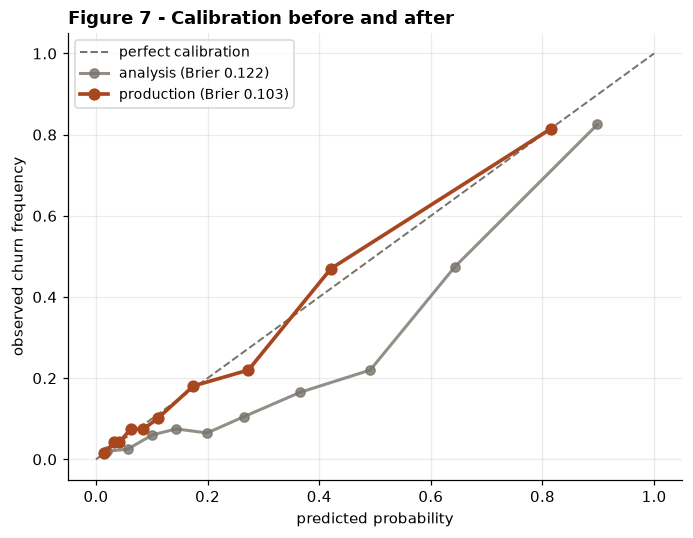

In [19]:
fr_a, mp_a = calibration_curve(y_test, proba,      n_bins=10, strategy="quantile")
fr_p, mp_p = calibration_curve(y_test, proba_prod, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(6.4, 5))
ax.plot([0, 1], [0, 1], "--", color=GREY, lw=1.3, label="perfect calibration")
ax.plot(mp_a, fr_a, "o-", color=GREY, lw=2, ms=6, alpha=0.8,
        label=f"analysis (Brier {brier:.3f})")
ax.plot(mp_p, fr_p, "o-", color=CHURN, lw=2.4, ms=7,
        label=f"production (Brier {brier_score_loss(y_test, proba_prod):.3f})")
ax.set_xlabel("predicted probability"); ax.set_ylabel("observed churn frequency")
ax.set_title("Figure 7 - Calibration before and after", fontsize=11.5,
             fontweight="bold", loc="left")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

### Persisting the production reference

Two tables, and **each has exactly one writer**:

| Table | Written by | Read by |
|---|---|---|
| `gold.production_model_base` | this notebook | notebook 06 |
| `gold.production_model` | notebook 06 | the app |

That split exists because of a real failure. When both notebooks wrote the same
table, every re-run of 05 wiped the Unity Catalog link that 06 had added, and the
only symptom was the app failing to load the model days later. **A shared artefact
needs a single writer.**

In [21]:
# MLflow serialises sklearn models with skops, which refuses to rebuild classes
# that are not on its allowlist -- a real protection, since a pickle can execute
# arbitrary code when loaded. CalibratedClassifierCV stores a list of private
# _CalibratedClassifier objects, so it has to be declared trusted explicitly.
TRUSTED = ["sklearn.calibration._CalibratedClassifier"]

RUN_PROD = None
try:
    run = mlflow.start_run(run_name="production_model")
    RUN_PROD = run.info.run_id          # captured first: the run exists from here on
    mlflow.log_params({"family": ref["family"], "gender_excluded": True,
                       "calibration": "isotonic_cv5"})
    mlflow.log_metrics({"test_roc_auc": float(roc_auc_score(y_test, proba_prod)),
                        "test_brier": float(brier_score_loss(y_test, proba_prod)),
                        "test_recall": float(m_prod["recall"]),
                        "test_precision": float(m_prod["precision"])})
    try:
        mlflow.sklearn.log_model(model_prod, name="model", skops_trusted_types=TRUSTED)
    except TypeError:
        # Older MLflow has no skops path; pickle is the only format there.
        mlflow.sklearn.log_model(model_prod, name="model")
except Exception as e:
    # Print the message, not just the type. A bare exception type says nothing
    # about whether this is permissions, a schema mismatch or a bad URI.
    print(f"[warn] MLflow step failed -- {type(e).__name__}: {e}")
finally:
    try:
        mlflow.end_run()
    except Exception:
        pass

print("production run:", RUN_PROD or "(not logged)")

prod_ref = pd.DataFrame([{
    "run_id": RUN_PROD or "", "family": ref["family"],
    "gender_excluded": True, "calibration": "isotonic_cv5",
    "threshold": float(thr_prod), "cost_threshold": float(BREAK_EVEN),
    "capacity_fraction": float(CAPACITY_FRACTION),
    "test_roc_auc": float(roc_auc_score(y_test, proba_prod)),
    "test_brier": float(brier_score_loss(y_test, proba_prod)),
}])

(spark.createDataFrame(prod_ref).write.format("delta").mode("overwrite")
      .option("overwriteSchema", "true")
      .saveAsTable(f"{UC_CATALOG}.gold.production_model_base"))

metrics_row = pd.DataFrame([{
    "model": ref["family"], "variant": "production", "run_id": RUN_PROD or "",
    "gender_excluded": True, "calibration": "isotonic_cv5",
    "threshold": float(thr_prod), "cost_threshold": float(BREAK_EVEN),
    "capacity_fraction": float(CAPACITY_FRACTION),
    "roc_auc": float(roc_auc_score(y_test, proba_prod)),
    "average_precision": float(average_precision_score(y_test, proba_prod)),
    "brier": float(brier_score_loss(y_test, proba_prod)),
    "recall": float(m_prod["recall"]), "precision": float(m_prod["precision"]),
    "f1": float(m_prod["f1"]), "accuracy": float(m_prod["accuracy"]),
    "tp": int(m_prod["TP"]), "fp": int(m_prod["FP"]),
    "fn": int(m_prod["FN"]), "tn": int(m_prod["TN"]),
    "recall_ceiling": float(ceiling), "pct_of_ceiling": float(pct_of_ceiling),
}])

(spark.createDataFrame(metrics_row).write.format("delta").mode("overwrite")
      .option("overwriteSchema", "true")
      .saveAsTable(f"{UC_CATALOG}.gold.model_metrics"))

print("written: gold.production_model_base and gold.model_metrics")

🔗 View Logged Model at: https://dbc-04c9ea21-2a95.cloud.databricks.com/ml/experiments/733594851517913/models/m-<run_id>


🏃 View run production_model at: https://dbc-04c9ea21-2a95.cloud.databricks.com/ml/experiments/733594851517913/runs/<run_id>
🧪 View experiment at: https://dbc-04c9ea21-2a95.cloud.databricks.com/ml/experiments/733594851517913
production run: <run_id>
written: gold.production_model_base and gold.model_metrics


---

## Summary

| | |
|---|---|
| Analysis model | Random forest with `gender`, uncalibrated |
| **Production model** | **Random forest without `gender`, isotonic calibration** |
| Threshold | Set by capacity, validated against break-even |
| Criteria met | 6 of 8 |
| Criteria failed | Recall ≥ 0.60 (impossible: ceiling) and country recall gap |

Neither failure was adjusted after the fact. The recall ceiling turned out to be
the most interesting result in the notebook.

**Next:** `06_gold_publication` — score the full portfolio, close the loop back to
Lakebase, and export the snapshot the public app reads.